In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sys
import csv
import re

In [90]:
# Read the .csv file
root = "C:\\Users\\rodri\\Downloads\\PhD\\Review_grounders\\keras_ns_grounders\\experiments\\countries\\hparamsearch\\"
path = root + "experiments_s_new.csv"
path = root + "experiments0601.csv"
path = root + "experiments_0501.csv"
path = root + "experiments_golia_20_01.csv"
path = root + "experiments_maxi_golia_20_01.csv"
df = pd.read_csv(path, sep=';')
df.head(5)

,Task,Grounder,KGE,EmbedSize,WeightLoss_Task,Reasoner_depth,Model_name,Time,train_loss,train_concept_loss,...,val_task_hits@3@3,test_loss,test_concept_loss,test_task_loss,test_concept_mrr,test_concept_hits@1@1,test_concept_hits@3@3,test_task_mrr,test_task_hits@1@1,"test_task_hits@3@3,,,,,,,,,,,,,,,,,,,,,,,,,,,,"
0,kinship_family,backward_1,complex,100,0.5,1,rnm,"[47.20494456291199, 0.8262842018988287]","[0.012, 0.0]","[0.012, 0.0]",...,"[0.0, 0.0]","[0.5253, 0.0056]","[0.5253, 0.0056]","[0.5253, 0.0056]","[0.5122, 0.0071]","[0.5, 0.0]","[0.5071, 0.0143]","[0.5122, 0.0071]","[0.5, 0.0]","[0.5071, 0.0143]"
1,kinship_family,backward_1,complex,100,0.5,1,dcr,"[58.763908338546756, 0.637659419268328]","[0.0445, 0.0]","[0.012, 0.0]",...,"[0.0, 0.0]","[0.5529, 0.0058]","[0.5242, 0.0059]","[0.5528, 0.0057]","[0.5113, 0.0046]","[0.5, 0.0]","[0.5, 0.0]","[0.5113, 0.0046]","[0.5, 0.0]","[0.5, 0.0]"
2,kinship_family,backward_1,complex,100,0.5,1,r2n,"[60.90785260200501, 0.6632394139954806]","[0.0133, 0.0001]","[0.012, 0.0]",...,"[0.0, 0.0]","[0.5247, 0.0056]","[0.5247, 0.0056]","[0.5247, 0.0056]","[0.5097, 0.0042]","[0.5, 0.0]","[0.5, 0.0]","[0.5097, 0.0042]","[0.5, 0.0]","[0.5, 0.0]"
3,kinship_family,backward_1,complex,100,0.5,1,sbr,"[47.50032548904419, 1.1369298216669066]","[0.012, 0.0]","[0.012, 0.0]",...,"[0.0, 0.0]","[0.5253, 0.0056]","[0.5253, 0.0056]","[0.5253, 0.0056]","[0.5122, 0.0071]","[0.5, 0.0]","[0.5071, 0.0143]","[0.5122, 0.0071]","[0.5, 0.0]","[0.5071, 0.0143]"
4,kinship_family,backward_1,complex,100,0.5,1,gsbr,"[49.096596813201906, 0.9339363982952433]","[0.0119, 0.0]","[0.012, 0.0]",...,"[0.0, 0.0]","[0.5253, 0.0056]","[0.5253, 0.0056]","[0.5253, 0.0056]","[0.5124, 0.0071]","[0.5, 0.0]","[0.5071, 0.0143]","[0.5124, 0.0071]","[0.5, 0.0]","[0.5071, 0.0143]"


In [91]:
# remove the duplicates in df
df = df.drop_duplicates( keep='first')

In [92]:
for column in df:
    try:
        # For all the colum, apply eval() to convert the string to a list
        if column != 'KGE':
            df[column] = [np.array(eval(i)) for i in df[column].values]
    except:
        # print("Error in ", column)
        continue

# for each col that is a string or int or object, print the unique values 
for col in df.columns:
    try: 
        if df[col].dtype == 'object' or df[col].dtype == 'int64' or df[col].dtype == 'string':
            print(df[col].unique())
            print(col)
            print()
    except:
        continue

# results = df.loc[(df['Grounder'] == 'known') & (df['KGE'] == 'distmult') & (df['EmbedSize'] == 10)]
# results

['kinship_family' 'nations_AMIE' 'nations_NCRL' 'countries_s1'
 'countries_s2' 'countries_s3']
Task

['backward_1' 'known' 'backward_2' 'backward_3' 'full' 'domainbody']
Grounder

['complex']
KGE

[100]
EmbedSize

[1]
Reasoner_depth

['rnm' 'dcr' 'r2n' 'sbr' 'gsbr' 'cdcr' 'no_reasoner']
Model_name



In [93]:
def split_df(df):
    # create a df that is the same as the original but with the first value of the colums in the list metrics
    df_mean = df.copy()
    for col in df_mean.columns:
        try:
            df_mean[col] = [i[0] for i in df_mean[col].values]
        except:
            continue
    # Do the same for the std
    df_std = df.copy()
    for col in df_std.columns:
        try:
            df_std[col] = [i[1] for i in df_std[col].values]
        except:
            continue
    return df_mean, df_std

In [94]:
cols = 'Grounder'
rows = 'Model_name'
metrics = ['test_task_mrr', 'Time']
KGEs = ['complex'] #, 'distmult', 'transe']
baseline_model = 'no_reasoner'
baseline_metric = 'test_concept_mrr'
tasks = ['countries_s1','countries_s2', 'countries_s3', 'nations_NCRL', 'nations_AMIE','kinship_family']

# Tables

One table for the different models with KGE complex (also for the other KGEs)
Another table for the different KGEs
Another table for the time with the best model and the best KGE

In [95]:
# Table 1: rows:grounder, cols:Model, values: mrr
csv_dir = "C:\\Users\\rodri\\Downloads\\PhD\\Review_grounders\\keras_ns_grounders\\experiments\\countries\\hparamsearch\\results.csv"
for task in tasks:
    for metric in metrics:
        for KGE in ['complex']: #, 'distmult', 'transe']:
            print('KGE: ', KGE, ' Metric: ', metric, ' Task: ', task)
            # filter the df
            results = df.loc[ (df['Task'] == task) &(df['KGE'] == KGE) ].copy() #& (df['WeightLoss_Task'] == 0.5) & (df['Reasoner_depth'] == 1) & (df['EmbedSize'] == 100)].copy()
            # take only the columns grounder, model, test_task_mrr, test_concept_mrr
            results = results[[cols, rows, metric]]#, 'test_concept_mrr']]
            # check if there are duplicates 
            # print(results.duplicated().sum())
            # put the model_name as colums
            results = results.pivot(index=rows, columns=cols, values=metric)
            if metric == 'test_task_mrr':
                # in the column no_reasoner, put the values of the column test_concept_mrr
                substitute = df.loc[(df['Task'] == task) & (df['KGE'] == KGE) & (df['Model_name'] == baseline_model) & (df['WeightLoss_Task'] == 0.5) & (df['Reasoner_depth'] == 1) & (df['EmbedSize'] == 100)][[cols,rows,baseline_metric]]
                substitute = substitute.pivot(index=rows, columns=cols, values=baseline_metric)
                # substitute the values in the table
                results.loc[baseline_model] = substitute.loc[baseline_model] 

            # with open(csv_dir, 'a') as f:
            #     f.write('\n Task : ,' + task + 'KGE : ,' + KGE + ', Metric: ,' + metric)
            #     f.write('\n ') 
            # results.to_csv(csv_dir, mode='a', header=True)  
results

KGE:  complex  Metric:  test_task_mrr  Task:  countries_s1
KGE:  complex  Metric:  Time  Task:  countries_s1
KGE:  complex  Metric:  test_task_mrr  Task:  countries_s2
KGE:  complex  Metric:  Time  Task:  countries_s2
KGE:  complex  Metric:  test_task_mrr  Task:  countries_s3
KGE:  complex  Metric:  Time  Task:  countries_s3
KGE:  complex  Metric:  test_task_mrr  Task:  nations_NCRL
KGE:  complex  Metric:  Time  Task:  nations_NCRL
KGE:  complex  Metric:  test_task_mrr  Task:  nations_AMIE
KGE:  complex  Metric:  Time  Task:  nations_AMIE
KGE:  complex  Metric:  test_task_mrr  Task:  kinship_family
KGE:  complex  Metric:  Time  Task:  kinship_family


Grounder,backward_1,known
Model_name,,
cdcr,"[65.84616045951843, 1.5086350977776268]","[62.43135724067688, 3.6508179407775874]"
dcr,"[58.763908338546756, 0.637659419268328]","[56.982030630111694, 2.0074882724007614]"
gsbr,"[49.096596813201906, 0.9339363982952433]","[48.47623224258423, 3.2513090118450245]"
no_reasoner,"[42.4407470703125, 1.856959856293092]","[43.16982545852661, 3.974367250609198]"
r2n,"[60.90785260200501, 0.6632394139954806]","[57.70014576911926, 2.4162836654135824]"
rnm,"[47.20494456291199, 0.8262842018988287]","[46.18693180084229, 1.7614434828432801]"
sbr,"[47.50032548904419, 1.1369298216669066]","[46.273440504074095, 3.0122983400674537]"


In [96]:
# # Table 1: rows:grounder, cols:Model, values: mrr
# csv_dir = "C:\\Users\\rodri\\Downloads\\PhD\\Review_grounders\\code\\keras-ns\\experiments\\countries\\hparamsearch\\results.csv"
# cols = 'Grounder'
# rows = 'KGE'
# metrics = ['test_task_mrr','Time']
# for metric in metrics:
#     for model in df['Model_name'].unique():
#         # filter the df
#         results = df.loc[ (df['Model_name'] == model) & (df['WeightLoss_Task'] == 0.5) & (df['Reasoner_depth'] == 1) & (df['EmbedSize'] == 100)].copy()
#         # take only the columns grounder, model, test_task_mrr, test_concept_mrr
#         results = results[[cols, rows, metric]]#, 'test_concept_mrr']]
#         # put the model_name as colums
#         results = results.pivot(index=rows, columns=cols, values=metric)
#         # print(results)
#         # with open(csv_dir, 'a') as f:
#         #     f.write('\nModel : ,' + model + ', Metric: ,' + metric)
#         #     f.write('\n ')
#         # results.to_csv(csv_dir, mode='a', header=True)  
# results

# PLOTS

In [97]:
step = 'test'
metric = step+'_task_mrr'
models = ['dcr','r2n','sbr','rnm','gsbr','cdcr']
baseline_metric = step+'_concept_mrr'
metrics = [step+'_task_mrr','Time']
metric_names = {step+'_task_mrr':'MRR', 'Time':'Time (s)'}

KGE:  complex  Metric:  test_task_mrr  Task:  countries_s1
Grounder     backward_1  backward_2  backward_3  domainbody    full   known
Model_name                                                                 
cdcr             0.9317      0.9238      0.9238      0.9368  0.9479  0.9317
dcr              0.9437      0.9238      0.9238      0.9208  0.9237  0.9437
gsbr             0.9313      0.9238      0.9238      0.9286  0.9277  0.9313
no_reasoner      0.9238      0.9238      0.9238      0.9238  0.9238  0.9238
r2n              0.9839      0.9242      0.9242      0.9275  0.9255  0.9839
rnm              0.9215      0.9238      0.9238      0.9275  0.9260  0.9215
sbr              0.9215      0.9238      0.9238      0.9275  0.9260  0.9215


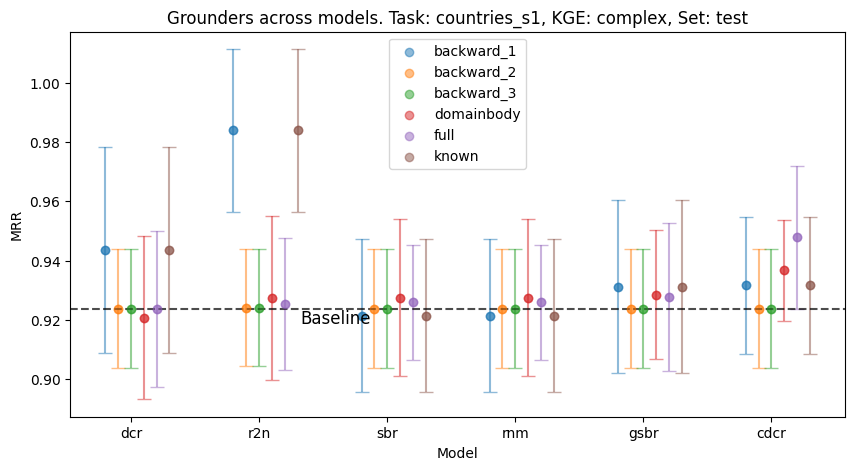

KGE:  complex  Metric:  Time  Task:  countries_s1
Grounder     backward_1  backward_2  backward_3  domainbody       full  \
Model_name                                                               
cdcr          18.041806   15.418619   15.520325   25.208637  33.669017   
dcr           16.935749   14.529333   14.546039   17.756384  24.414843   
gsbr          13.047886   15.916459   16.187516   14.192035  15.343098   
no_reasoner   12.188575   15.080579   15.415771   12.093727  12.101023   
r2n           13.568389   16.426389   16.482864   21.264060  23.425379   
rnm           15.331545   15.529256   12.917592   17.072523  14.655733   
sbr           15.172848   12.782287   12.807305   13.686551  17.884845   

Grounder         known  
Model_name              
cdcr         18.219631  
dcr          17.054754  
gsbr         12.996310  
no_reasoner  12.164213  
r2n          13.566613  
rnm          15.435419  
sbr          15.344727  


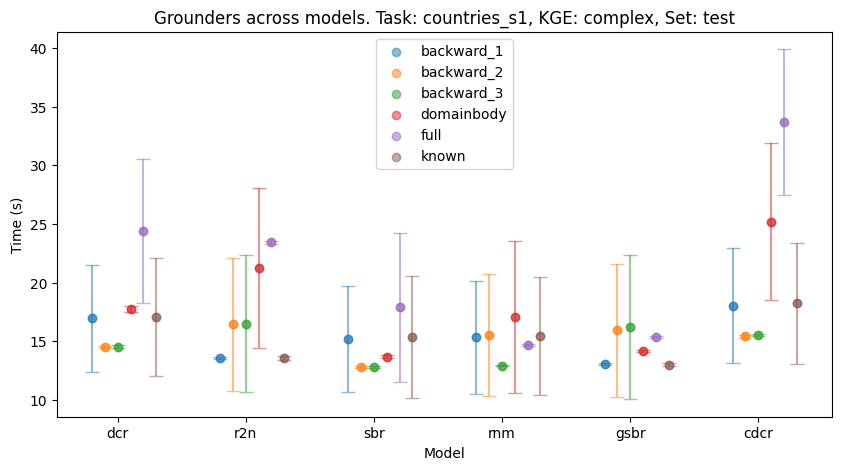

KGE:  complex  Metric:  test_task_mrr  Task:  countries_s2
Grounder     backward_1  backward_2  backward_3   known
Model_name                                             
cdcr             0.9189      0.9088      0.9088  0.9149
dcr              0.9189      0.9088      0.9088  0.9153
gsbr             0.9147      0.9088      0.9088  0.9127
no_reasoner      0.9088      0.9088      0.9088  0.9088
r2n              0.9213      0.9083      0.9083  0.9154
rnm              0.9141      0.9088      0.9088  0.9141
sbr              0.9141      0.9088      0.9088  0.9141


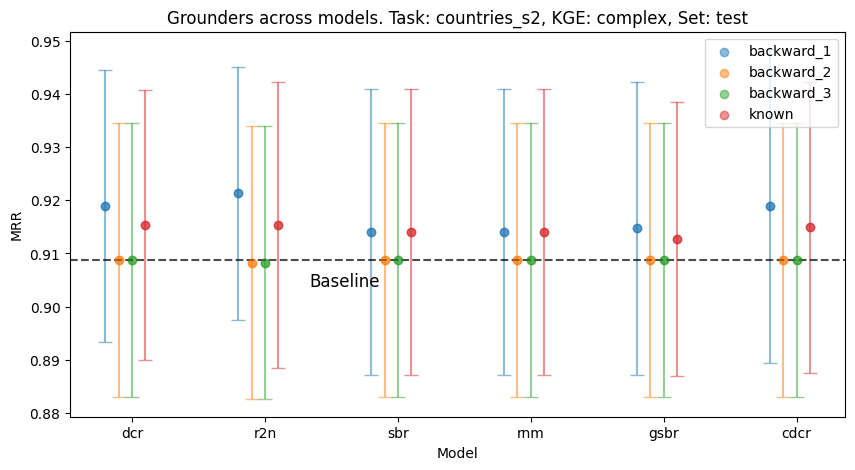

KGE:  complex  Metric:  Time  Task:  countries_s2
Grounder     backward_1  backward_2  backward_3      known
Model_name                                                
cdcr          19.432482   37.549510   76.935929  21.068469
dcr           17.759423   35.479407   75.815682  15.262411
gsbr          15.045560   36.626442   73.176793  12.604650
no_reasoner   15.980963   12.118070   12.214292  12.134004
r2n           15.614140   33.152559   73.522551  17.308468
rnm           18.270083   32.285466   72.815083  12.220967
sbr           18.376671   32.360780   68.601225  12.278207


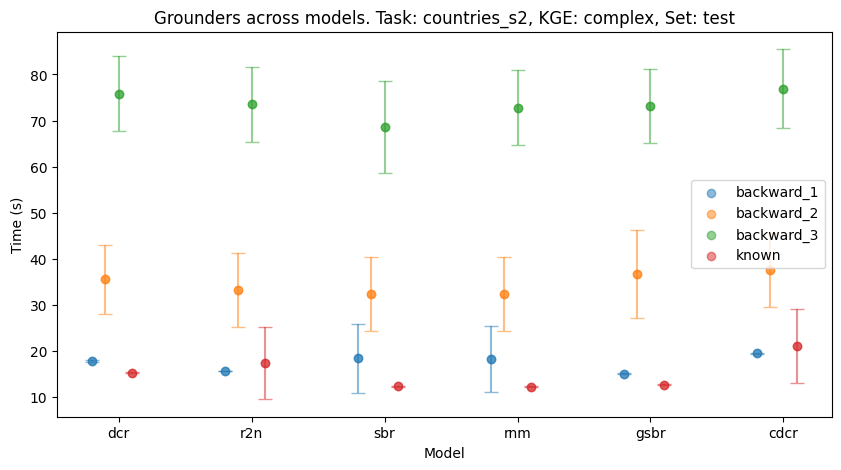

KGE:  complex  Metric:  test_task_mrr  Task:  countries_s3
Grounder     backward_1  backward_2  backward_3   known
Model_name                                             
cdcr             0.9082      0.8148      0.8148  0.8286
dcr              0.8634      0.8148      0.8148  0.8305
gsbr             0.8271      0.8148      0.8148  0.8323
no_reasoner      0.8220      0.8220      0.8220  0.8220
r2n              0.8661      0.8151      0.8151  0.8301
rnm              0.8238      0.8148      0.8148  0.8303
sbr              0.8238      0.8148      0.8148  0.8303


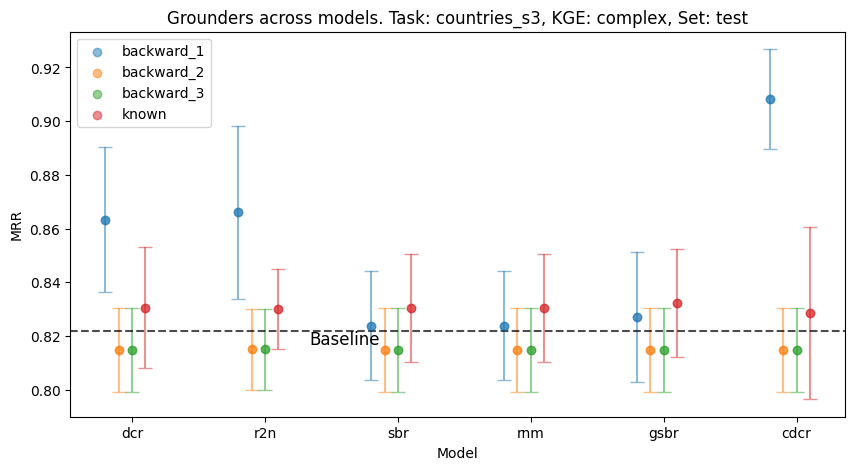

KGE:  complex  Metric:  Time  Task:  countries_s3
Grounder     backward_1  backward_2  backward_3      known
Model_name                                                
cdcr          30.593271  170.788102  315.291563  23.371519
dcr           27.748599  166.120798  311.895228  24.416449
gsbr          19.282644  162.671688  301.463734  19.619490
no_reasoner   12.171915   17.166781   12.124370  12.182907
r2n           19.901525  162.162750  302.507044  16.136480
rnm           18.666668  165.224797  304.871859  13.827433
sbr           18.725729  159.386072  303.925248  13.714506


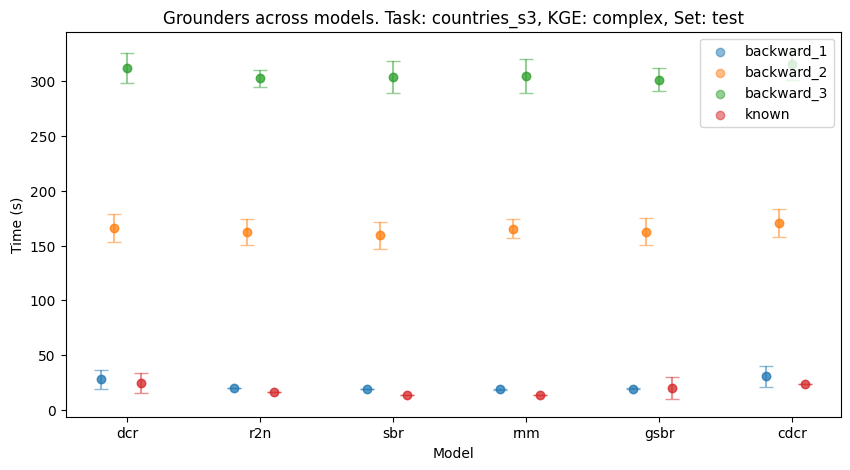

KGE:  complex  Metric:  test_task_mrr  Task:  nations_NCRL
Grounder     backward_1  backward_2  backward_3   known
Model_name                                             
cdcr             0.7066      0.7076      0.7015  0.7076
dcr              0.7031      0.7076      0.7076  0.7076
gsbr             0.7030      0.7076      0.7015  0.7076
no_reasoner      0.7085      0.7085      0.6993  0.7085
r2n              0.6994      0.7061      0.6990  0.7061
rnm              0.7052      0.7076      0.7076  0.7076
sbr              0.7052      0.7076      0.7015  0.7076


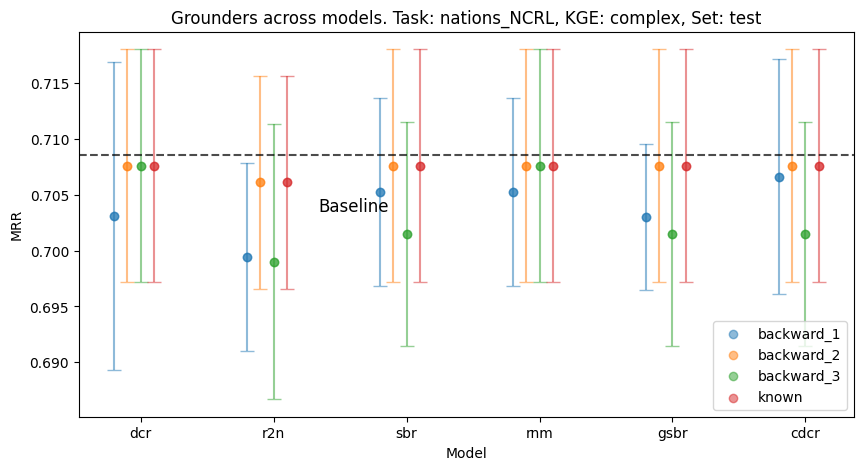

KGE:  complex  Metric:  Time  Task:  nations_NCRL
Grounder     backward_1   backward_2   backward_3       known
Model_name                                                   
cdcr         273.448676  1258.459519   265.459162  278.061784
dcr          211.360509   211.694279  1849.049443  218.087318
gsbr         107.956227   415.886823   100.490951  110.764765
no_reasoner   73.731774   477.963606    64.206973   57.284261
r2n          121.741116   211.305365   112.261586  124.188564
rnm           79.662326   100.844296   509.001488   80.510519
sbr           94.900171   143.196359    87.195681   79.825774


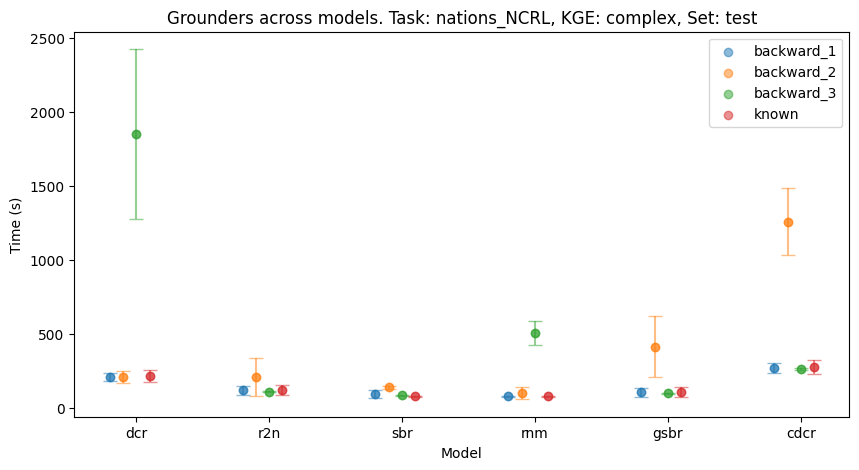

KGE:  complex  Metric:  test_task_mrr  Task:  nations_AMIE
Grounder     backward_1  backward_2  backward_3   known
Model_name                                             
cdcr             0.7017      0.7076      0.7076  0.7029
dcr              0.7096      0.7076      0.7076  0.7012
gsbr             0.7008      0.7076      0.7076  0.7048
no_reasoner      0.7085      0.7085      0.7085  0.7085
r2n              0.7058      0.7061      0.7061  0.7030
rnm              0.6993      0.7076      0.7076  0.7063
sbr              0.6993      0.7076      0.7076  0.7063


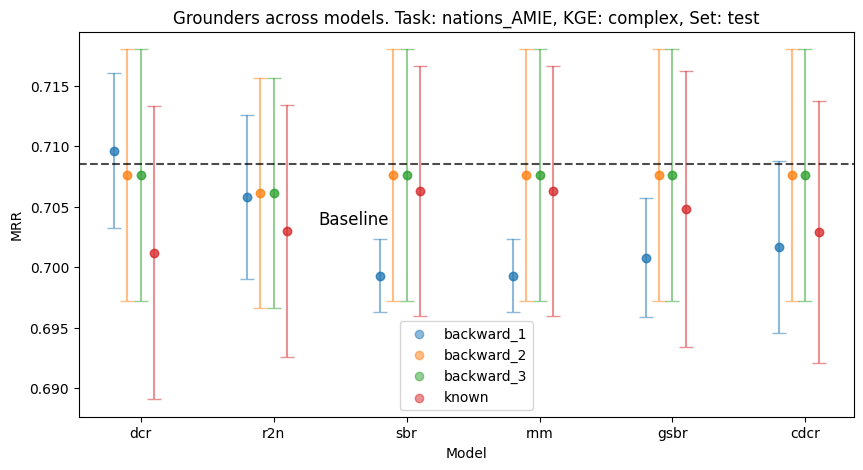

KGE:  complex  Metric:  Time  Task:  nations_AMIE
Grounder     backward_1  backward_2  backward_3       known
Model_name                                                 
cdcr         213.357135  214.170628  211.714976  215.988809
dcr          166.709566  162.913497  168.592404  169.206920
gsbr          94.955175   97.682044   95.348685   91.929595
no_reasoner   67.711576   68.126555   70.425773   64.735462
r2n          107.006836  106.309296  103.851055  106.449692
rnm           81.117012   86.733516   83.217662   83.585489
sbr           82.930001   81.178591   85.355583   82.791959


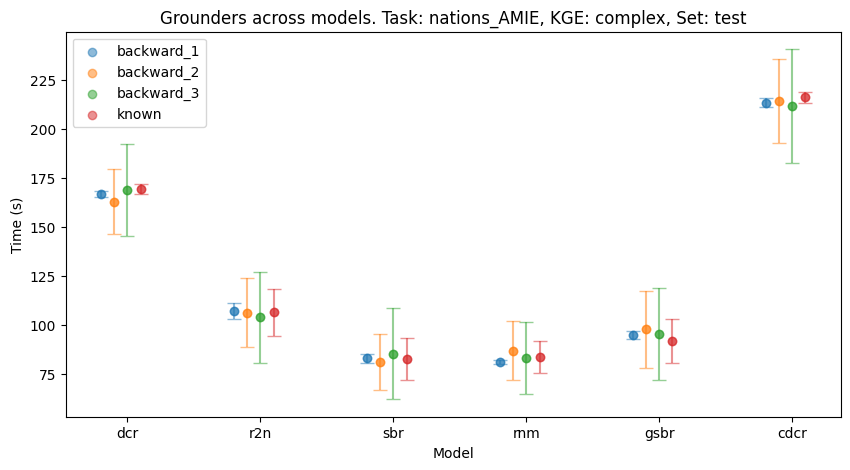

KGE:  complex  Metric:  test_task_mrr  Task:  kinship_family
Grounder     backward_1   known
Model_name                     
cdcr             0.5107  0.5103
dcr              0.5113  0.5107
gsbr             0.5124  0.5108
no_reasoner      0.5140  0.5140
r2n              0.5097  0.5103
rnm              0.5122  0.5108
sbr              0.5122  0.5108


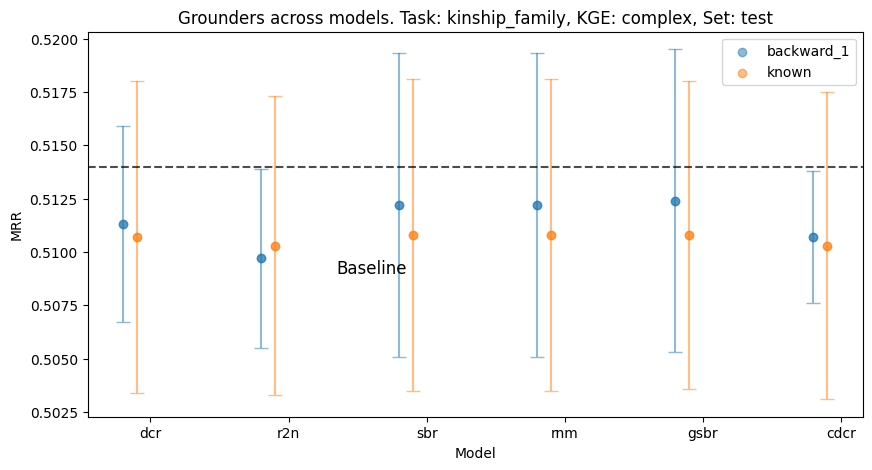

KGE:  complex  Metric:  Time  Task:  kinship_family
Grounder     backward_1      known
Model_name                        
cdcr          65.846160  62.431357
dcr           58.763908  56.982031
gsbr          49.096597  48.476232
no_reasoner   42.440747  43.169825
r2n           60.907853  57.700146
rnm           47.204945  46.186932
sbr           47.500325  46.273441


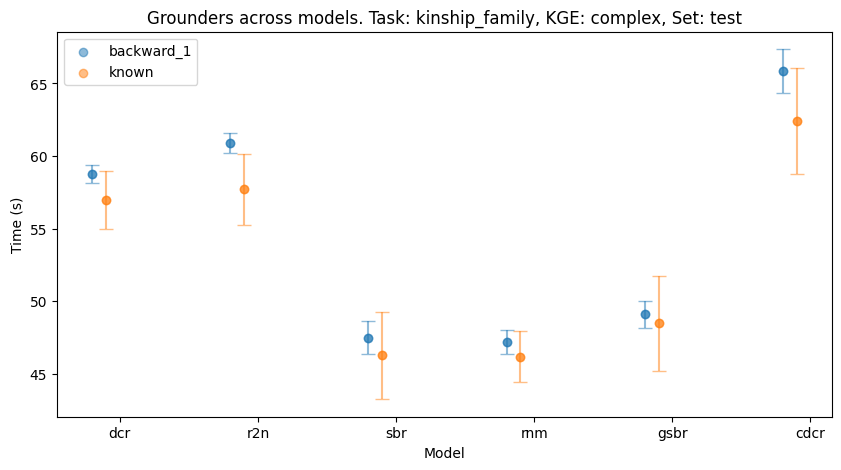

In [98]:
# Table 1: rows:grounder, cols:Model, values: mrr
root_dir = "C:\\Users\\rodri\\Downloads\\PhD\\Review_grounders\\keras_ns_grounders\\experiments\\countries\\hparamsearch\\"
for task in tasks:
    for metric in metrics:
        for KGE in KGEs:
            print('KGE: ', KGE, ' Metric: ', metric, ' Task: ', task)
            # filter the df
            results = df.loc[(df['Task'] == task) & (df['KGE'] == KGE) ].copy() #& (df['WeightLoss_Task'] == 0.5) & (df['Reasoner_depth'] == 1) & (df['EmbedSize'] == 100)].copy()
            # take only the columns grounder, model, test_task_mrr, test_concept_mrr
            results = results[[cols, rows, metric]]#, 'test_concept_mrr']]
            # put the model_name as colums
            results = results.pivot(index=rows, columns=cols, values=metric)

            if metric == step+'_task_mrr':
                # in the column no_reasoner, put the values of the columnstep+ _concept_mrr
                substitute = df.loc[(df['Task'] == task) & (df['KGE'] == KGE) & (df['Model_name'] == baseline_model) ][[cols,rows,baseline_metric]] # & (df['WeightLoss_Task'] == 0.5) & (df['Reasoner_depth'] == 1) & (df['EmbedSize'] == 100)][[cols,rows,baseline_metric]]
                substitute = substitute.pivot(index=rows, columns=cols, values=baseline_metric)
                # substitute the values in the table
                results.loc[baseline_model] = substitute.loc[baseline_model]
            df_mean, df_std = split_df(results)
            print(df_mean)
            # Remove no reasoner and include a line where it is written baseline
            plt.figure(figsize=(10,5))
            for i,grounder in enumerate(df_mean.columns):
                plt.scatter(np.arange(len(df_mean.loc[models].index))+0.1*i, df_mean.loc[models][grounder], label=grounder, alpha=0.5)
                plt.errorbar(np.arange(len(df_mean.loc[models].index))+0.1*i, df_mean.loc[models][grounder], yerr=df_std.loc[models][grounder], fmt='o',capsize=5, alpha=0.5)
            if metric == step+'_task_mrr':
                plt.axhline(y=df_mean.loc[baseline_model].values[0], color='black', linestyle='--', alpha=.7)  # Change color and linestyle as desired
                plt.text(1.8, df_mean.loc[baseline_model].values[0]-0.005, 'Baseline', color='black', fontsize=12, ha='center')
                # print(df_mean.loc[baseline_model].values[0])
            plt.legend()
            plt.xticks(np.arange(len(df_mean.loc[models].index))+0.2, df_mean.loc[models].index.tolist(), rotation=0)
            plt.ylabel(metric_names[metric])
            plt.xlabel('Model')
            plt.title(f'Grounders across models. Task: {task}, KGE: {KGE}, Set: {step}')
            plt.show()
            # SAVE THE FIGURE
            # plt.savefig(root_dir+'figures\\Grounders_across_models__'+'Task_'+task+'_Metric_'+metric+'_KGE_'+KGE+'.png', dpi=300, bbox_inches='tight')  

In [10]:
# cols = 'Grounder'
# rows = 'KGE'
# metric = 'test_task_mrr'
# baseline_model = 'no_reasoner'
# baseline_metric = 'test_concept_mrr'
# for metric in ['test_task_mrr', 'Time']:
#     for model in df['Model_name'].unique():
#         if model !='no_reasoner':
#             # filter the df
#             results = df.loc[ (df['Model_name'] == model) & (df['WeightLoss_Task'] == 0.5) & (df['Reasoner_depth'] == 1) & (df['EmbedSize'] == 100)].copy()
#             # take only the columns grounder, model, test_task_mrr, test_concept_mrr
#             results = results[[cols, rows, metric]]#, 'test_concept_mrr']]
#             # put the model_name as colums
#             results = results.pivot(index=rows, columns=cols, values=metric)

#             df_mean, df_std = split_df(results)
#             # Remove no reasoner and include a line where it is written baseline
#             plt.figure(figsize=(10,5))
#             for i,grounder in enumerate(df_mean.columns):
#                 plt.scatter(np.arange(len(df_mean.index))+0.1*i, df_mean[grounder], label=grounder, alpha=0.5)
#                 plt.errorbar(np.arange(len(df_mean.index))+0.1*i, df_mean[grounder], yerr=df_std[grounder], fmt='o',capsize=5, alpha=0.5)
#             plt.legend()
#             plt.xticks(np.arange(len(df_mean.index))+0.1*i, df_mean.index.tolist(), rotation=0)
#             plt.ylabel('MRR test')
#             plt.xlabel('KGE')
#             plt.title(f'Grounders across KGEs for model {model}')
#             plt.show()
#             # plt.savefig(root_dir+'figures\\Grounders_across_KGE___Model_'+model+'.png', dpi=300, bbox_inches='tight')  